<a href="https://colab.research.google.com/github/VanissaRzky-prstya/KueKita_website/blob/main/KBL_Modul1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

#setting visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi']=100
%matplotlib inline

In [5]:
#Membaca dataset yang sudah di-upload ke folder /content/
df = pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')

#Menampilkan ringkasan dataset
print("=" * 60)
print("HEART FAILURE PREDICITION DATASET")
print("=" * 60)
print(f"\nUkuran Dataset: {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"\nKolom: {list(df.columns)}")

HEART FAILURE PREDICITION DATASET

Ukuran Dataset: 299 baris x 13 kolom

Kolom: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']


In [6]:
#Menampilkan 5 data pertama
print("\n5 Data Pertama:")
df.head()
print("\n" + "=" * 60)
print("DESKRIPSI FITUR")
print("=" * 60)
feature_desc = {
    'age': 'Usia pasien (tahun)',
    'anaemia': 'Penurunan sel darah merah (0: tidak, 1: ya)',
    'creatinine_phosphokinase': 'Tingkat enzim CPK dalam darah (mcg/L)',
    'diabetes': 'Jika pasien menderita diabetes (0: tidak, 1: ya)',
    'ejection_fraction': 'Persentase darah yang keluar dari jantung per kontraksi (%)',
    'high_blood_pressure': 'Jika pasien menderita hipertensi (0:tidak, 1: ya)',
    'platelets': 'Trombosit dalam darah (kiloplatelet/ml)',
    'serum_creatinine': 'Tingkat kreatinin serum dalam darah (mg/dL)',
    'serum_sodium': 'Tingkat natrium serum dalam darah (mEq/L)',
    'sex': 'Jenis kelamin (0: perempuan, 1: laki-laki)',
    'smoking': 'Jika pasien merokok (0: tidak, 1: ya)',
    'time': 'Periode tindak lanjut (hari)',
    'DEATH_EVENT': 'Jika pasien meninggal selama periode tindak lanjut (0: tidak, 1: ya) - TARGET'
}

for feat, desc in feature_desc.items():
  print(f"- {feat}: {desc}")


5 Data Pertama:

DESKRIPSI FITUR
- age: Usia pasien (tahun)
- anaemia: Penurunan sel darah merah (0: tidak, 1: ya)
- creatinine_phosphokinase: Tingkat enzim CPK dalam darah (mcg/L)
- diabetes: Jika pasien menderita diabetes (0: tidak, 1: ya)
- ejection_fraction: Persentase darah yang keluar dari jantung per kontraksi (%)
- high_blood_pressure: Jika pasien menderita hipertensi (0:tidak, 1: ya)
- platelets: Trombosit dalam darah (kiloplatelet/ml)
- serum_creatinine: Tingkat kreatinin serum dalam darah (mg/dL)
- serum_sodium: Tingkat natrium serum dalam darah (mEq/L)
- sex: Jenis kelamin (0: perempuan, 1: laki-laki)
- smoking: Jika pasien merokok (0: tidak, 1: ya)
- time: Periode tindak lanjut (hari)
- DEATH_EVENT: Jika pasien meninggal selama periode tindak lanjut (0: tidak, 1: ya) - TARGET


In [7]:
#informasi tipe data
print("\nInformasi Tipe Data:")
df.info()


Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5

In [8]:
#Statistik deskriptif
print("\nStatistik Deskriptif: ")
df.describe()


Statistik Deskriptif: 


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [9]:
#buat copy dataset untuk cleaning
df_clean = df.copy()

#cek missing values
print("=" * 50)
print("ANALISIS MISSING VALUES")
print("=" * 50)

missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print(missing_df)
print(f"\nTotal missing values: {missing.sum()}")

ANALISIS MISSING VALUES
                          Missing Count  Percentage
age                                   0         0.0
anaemia                               0         0.0
creatinine_phosphokinase              0         0.0
diabetes                              0         0.0
ejection_fraction                     0         0.0
high_blood_pressure                   0         0.0
platelets                             0         0.0
serum_creatinine                      0         0.0
serum_sodium                          0         0.0
sex                                   0         0.0
smoking                               0         0.0
time                                  0         0.0
DEATH_EVENT                           0         0.0

Total missing values: 0


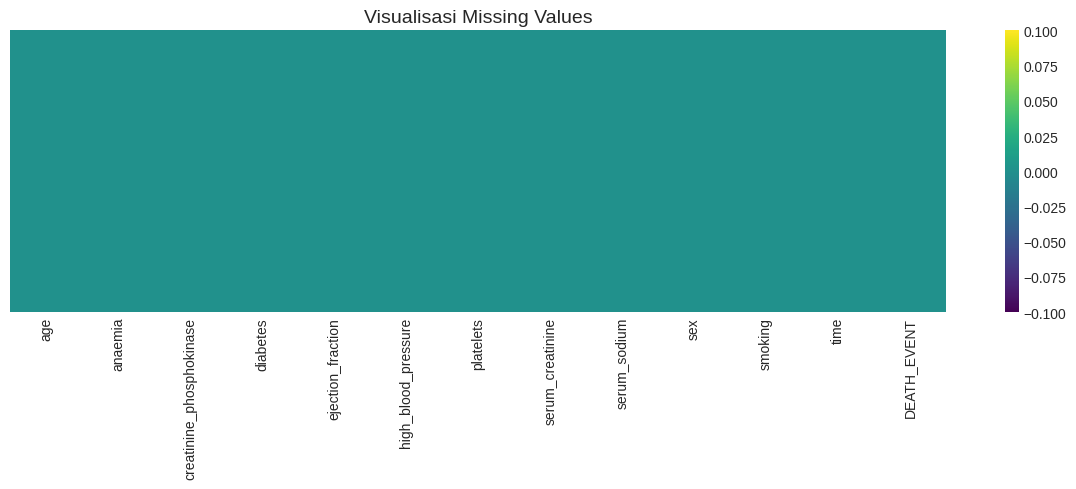

In [10]:
#visualisasi missing values
plt.figure(figsize=(12, 5))
sns.heatmap(df_clean.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Visualisasi Missing Values', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
#demonstrasi handling missing values
print("Metode Handling Missing Values:")
print("\n1. dropna() - Menghapus baris dengan missing values")
print("2. fillna() - Mengisi missing values (mean/median/mode)")
print("3. interpolate() - Interpolasi untuk data time series")

#contoh interpolasi
ts_data = pd.Series([1, 2, np.nan, np.nan, 5, 6, np.nan, 8, 9, 10])
print("\nData asli dengan missing:")
print("ts_data.values")

ts_interpolated = ts_data.interpolate(method='linear')
print("\nSetelah interpolasi linear:")
print("ts_interpolated.values")

Metode Handling Missing Values:

1. dropna() - Menghapus baris dengan missing values
2. fillna() - Mengisi missing values (mean/median/mode)
3. interpolate() - Interpolasi untuk data time series

Data asli dengan missing:
ts_data.values

Setelah interpolasi linear:
ts_interpolated.values


In [12]:
#cek duplikasi
duplicates = df_clean.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicates}")

if duplicates > 0:
  df_clean = df_clean.drop_duplicates()
  print(f"Ukuran setelah menghapus duplikat: {df_clean.shape}")
else:
    print("Tidak ada data duplikat.")

Jumlah baris duplikat: 0
Tidak ada data duplikat.


In [13]:
#reset ke data original untuk EDA
df_eda = df.copy()

#hitung survival rate
survival_rate = (1 - df_eda['DEATH_EVENT'].mean()) * 100
death_rate = df_eda['DEATH_EVENT'].mean() * 100

print("=" * 60)
print("SURVIVAL ANALYSIS")
print("=" * 60)
print(f"Survival Rate: {survival_rate:.2f}%")
print(f"Death Rate: {death_rate:.2f}%")
print(f"\n✓ Dataset cukup balanced untuk klarifikasi")

SURVIVAL ANALYSIS
Survival Rate: 67.89%
Death Rate: 32.11%

✓ Dataset cukup balanced untuk klarifikasi


In [14]:
#age group analysis
df_eda['age_group'] = pd.cut(df_eda['age'], bins=[0, 50, 60, 70, 100],
                             labels=['<50', '50-60', '60-70', '>70'])

age_death = df_eda.groupby('age_group')['DEATH_EVENT'].agg(['mean', 'count'])
age_death['death_rate_%'] = age_death['mean'] * 100

print("\nDeath Rate by Age Group:")
print(age_death)
print(f"\n✓ Pasien >70 tahun memiliki risiko tertinggi")


Death Rate by Age Group:
               mean  count  death_rate_%
age_group                               
<50        0.256757     74     25.675676
50-60      0.284091     88     28.409091
60-70      0.247059     85     24.705882
>70        0.596154     52     59.615385

✓ Pasien >70 tahun memiliki risiko tertinggi


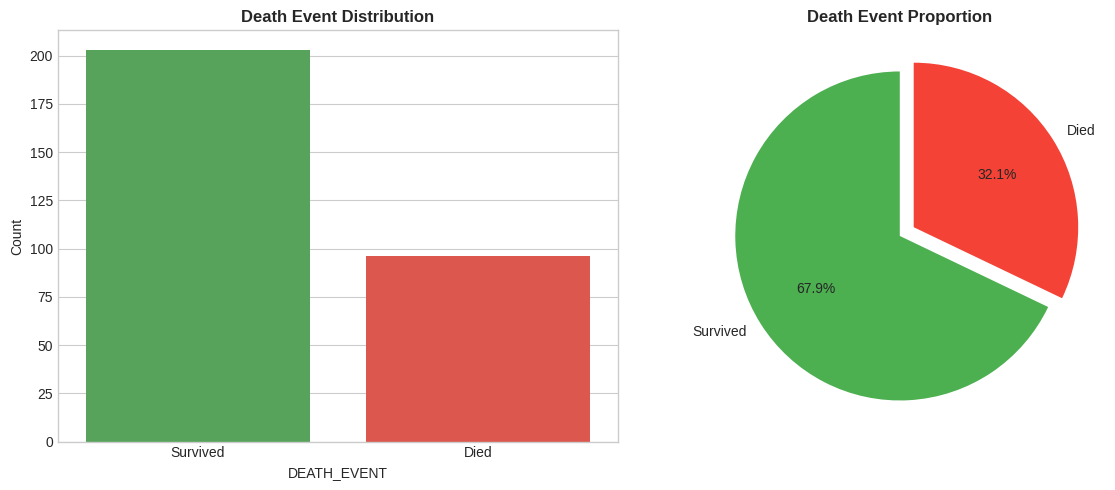

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(data=df_eda, x='DEATH_EVENT', ax=ax[0], palette=['#4CAF50',
                                                               '#F44336'])
ax[0].set_title('Death Event Distribution', fontsize=12, fontweight='bold')
ax[0].set_xticklabels(['Survived', 'Died'])
ax[0].set_ylabel('Count')

# Pie chart
sizes = df_eda['DEATH_EVENT'].value_counts()
ax[1].pie(sizes, labels=['Survived', 'Died'], autopct='%1.1f%%',
          colors=['#4CAF50', '#F44336'], explode=[0, 0.1], startangle=90)
ax[1].set_title('Death Event Proportion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

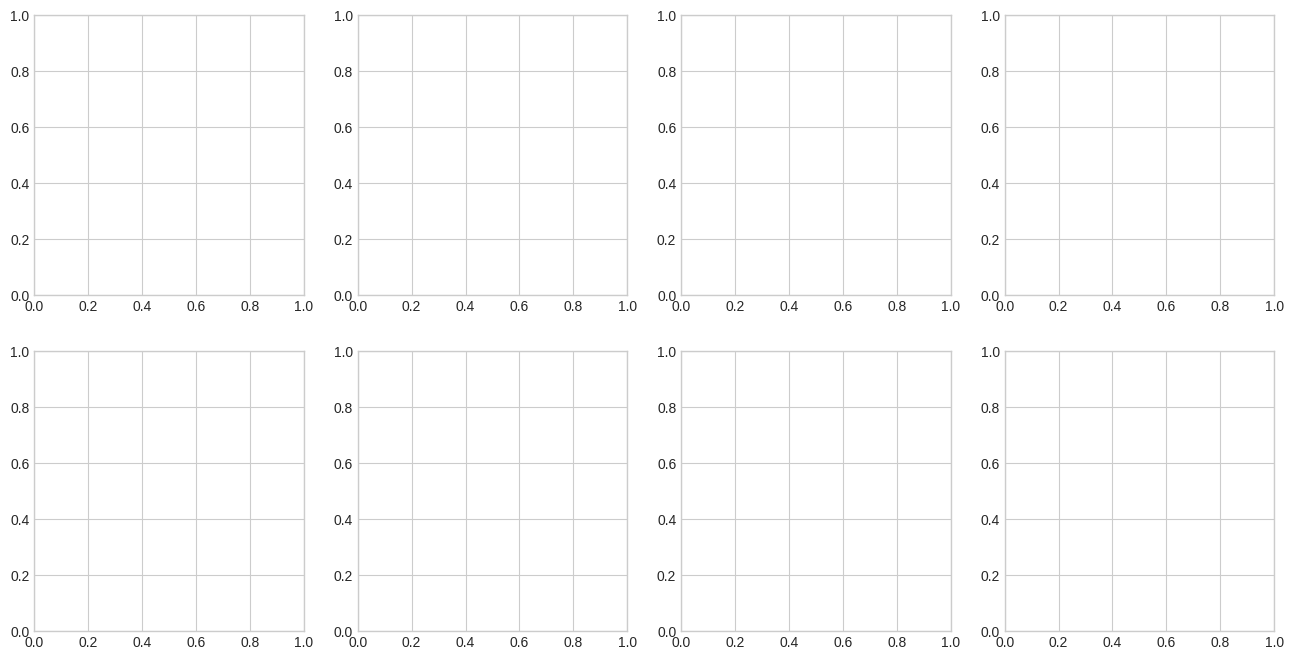

In [16]:
# Identifikasi kolom numerik
numerical_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
                  'platelets', 'serum_creatinine', 'serum_sodium', 'time']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

In [17]:
for idx, col in enumerate(numerical_cols):
  df_eda.boxplot(column=col, by='DEATH_EVENT', ax=axes[idx])
  axes[idx].set_title(f'{col}')
  axes[idx].set_xlabel('Death Event (0=Survived, 1=Died)')
  axes[idx].set_ylabel('')

axes[-1].axis('off')
plt.suptitle('Numeric Features Comparison', y=1.00, fontsize=14,
             fontweight='bold')
plt.tight_layout()
plt.show()

print("KEY INSIGHTS:")
print("✓ Ejection Fraction: Pasien meninggal memiliki EF lebih rendah")
print("✓ Serum Creatinine: Lebih tinggi pada pasien yang meninggal")
print("✓ Age: Pasien yang meninggal cenderung lebih tua")

<Figure size 640x480 with 0 Axes>

KEY INSIGHTS:
✓ Ejection Fraction: Pasien meninggal memiliki EF lebih rendah
✓ Serum Creatinine: Lebih tinggi pada pasien yang meninggal
✓ Age: Pasien yang meninggal cenderung lebih tua


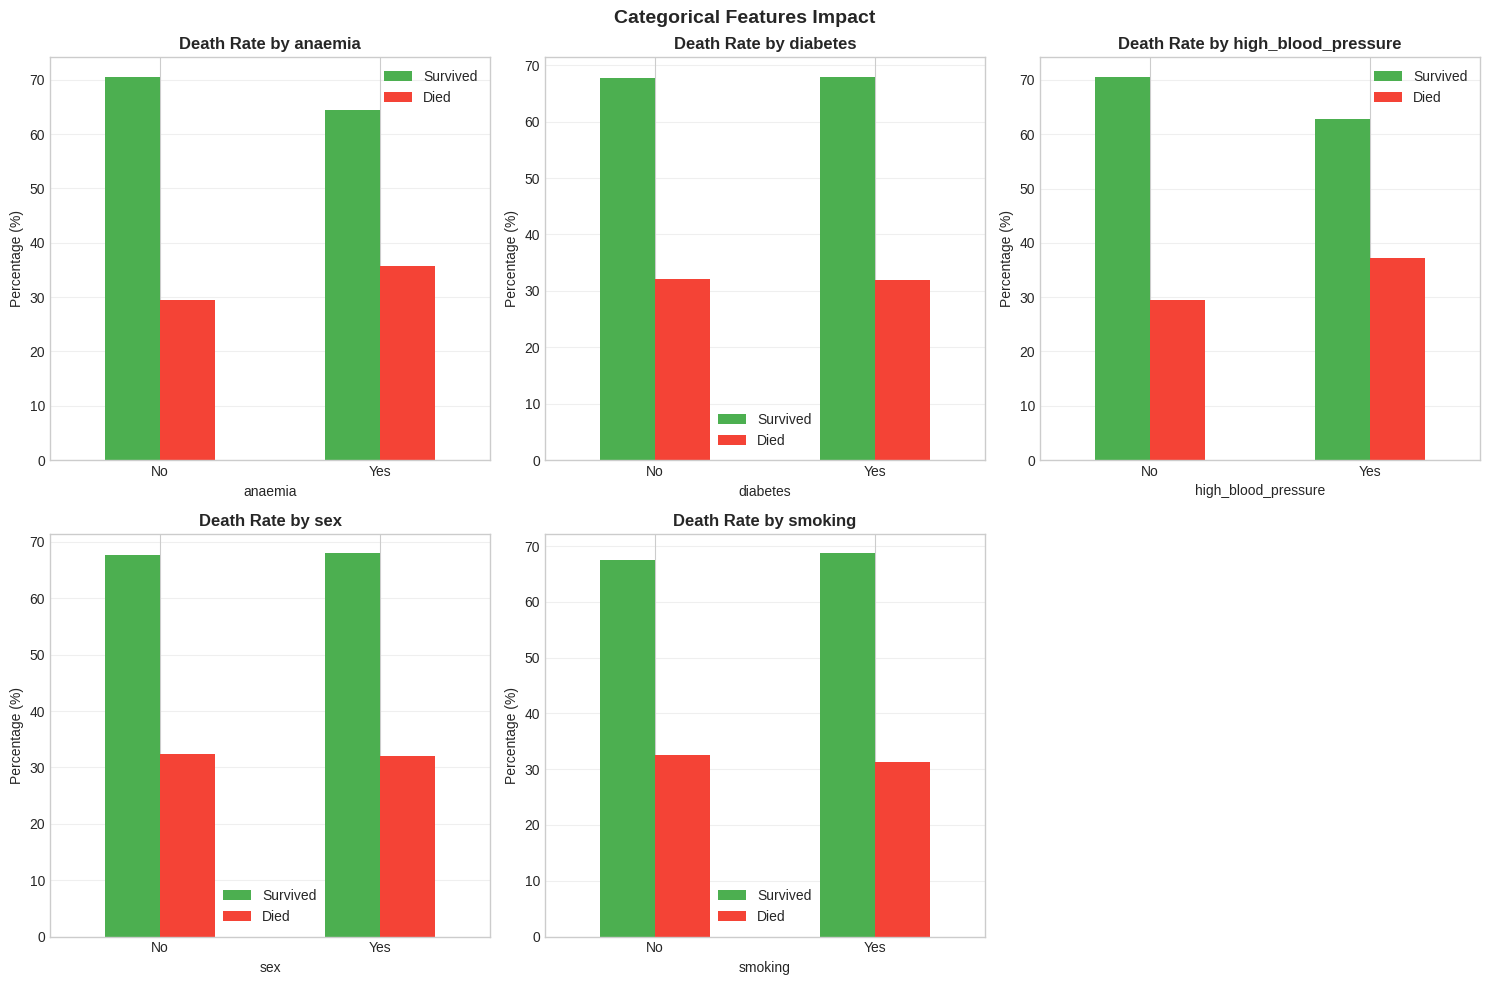

KEY INSIGHTS:
✓ Anaemia: Death rate lebih tinggi (40% vs 28%)
✓ High BP: Sedikit meningkatkan risiko


In [19]:
categorical_cols = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex',
                    'smoking']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
  crosstab = pd.crosstab(df_eda[col], df_eda['DEATH_EVENT'], normalize='index') * 100
  crosstab.plot(kind='bar', ax=axes[idx], color=['#4CAF50', '#F44336'])
  axes[idx].set_title(f'Death Rate by {col}', fontweight='bold')
  axes[idx].set_ylabel('Percentage (%)')
  axes[idx].set_xlabel(col)
  axes[idx].legend(['Survived', 'Died'])
  axes[idx].set_xticklabels(['No', 'Yes'], rotation=0)
  axes[idx].grid(axis='y', alpha=0.3)

axes[-1].axis('off')
plt.suptitle('Categorical Features Impact', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("KEY INSIGHTS:")
print("✓ Anaemia: Death rate lebih tinggi (40% vs 28%)")
print("✓ High BP: Sedikit meningkatkan risiko")

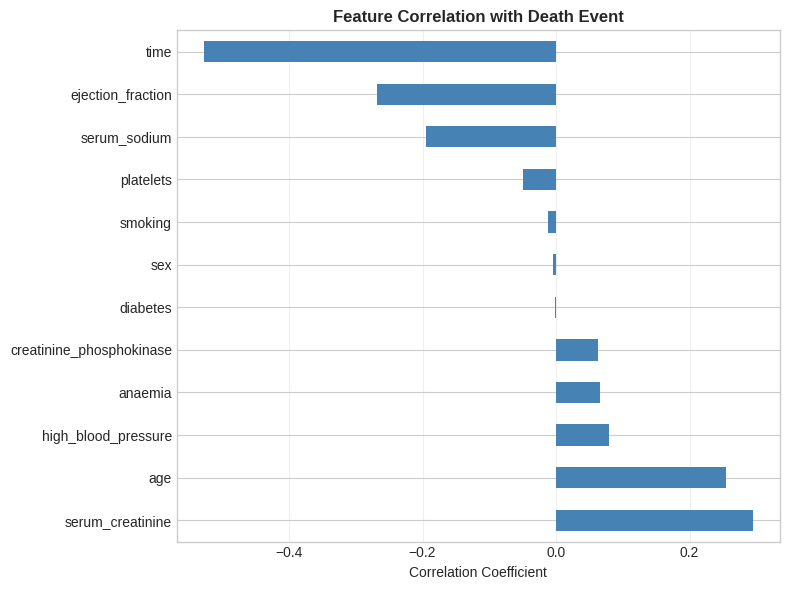

Top Positive Correlations:
serum_creatinine            0.294278
age                         0.253729
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
Name: DEATH_EVENT, dtype: float64

Top Negative Correlations:
smoking             -0.012623
platelets           -0.049139
serum_sodium        -0.195204
ejection_fraction   -0.268603
time                -0.526964
Name: DEATH_EVENT, dtype: float64


In [22]:
# Correlation dengan target
correlations = df_eda.corr(numeric_only=True)['DEATH_EVENT'].sort_values(ascending=False)

plt.figure(figsize=(8, 6))
correlations.drop('DEATH_EVENT').plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with Death Event', fontsize=12, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print("Top Positive Correlations:")
print(correlations.head(6)[1:])
print("\nTop Negative Correlations:")
print(correlations.tail(5))